In [37]:
import random
import torch

n = random.randint(2, 6)
iC = random.randint(2, 6)
oC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 6)
kW = random.randint(2, 6)

input = torch.rand(n, iC, H, W, dtype=torch.float32)
kernel = torch.rand(oC, iC, kH, kW, dtype=torch.float32)

In [38]:
input.shape

torch.Size([2, 5, 15, 12])

In [39]:
kernel.shape

torch.Size([6, 5, 6, 4])

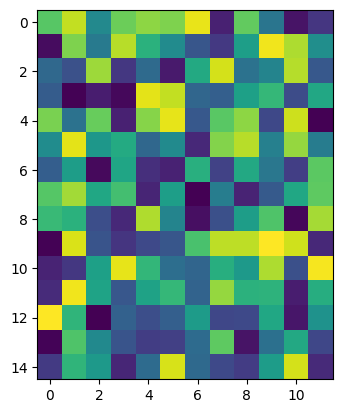

In [40]:
import matplotlib.pyplot as plt

plt.imshow(input[0,0,:,:])

In [ ]:
h_out = input.shape[2] - kernel.shape[2] + 1
w_out = input.shape[3] - kernel.shape[3] + 1
output = torch.zeros((input.shape[0], kernel.shape[0], h_out, w_out))
print(f"output.shape = {output.shape}")

output.shape = torch.Size([2, 6, 10, 9])


## Solution 1: slide window for each image in the batch

In [42]:
# input = ( n, iC, H, W )
# kernel = ( oC, iC, kH, kW )
# output = ( oC, iC, H - kH + 1, W - kW + 1 )

for i in range(input.shape[0]):  # For each image in the batch
    im = input[i]   # (iC, H, W)

    for j in range(kernel.shape[0]):     # For each filter of the kernel
        ker = kernel[j]     # (iC, kH, kW)

        for y in range(h_out):
            for x in range(w_out):
                window = im[:, y : (y + kH), x : (x + kW)]
                output[i, j, y, x] = torch.sum(window * ker)


## Solution 2: `unsqueeze`

In [43]:
# input = ( n, iC, H, W )
# kernel = ( oC, iC, kH, kW )
# output = ( oC, iC, H - kH + 1, W - kW + 1 )

view_kernel = kernel.unsqueeze(0)   # (1, oC, iC, kH, kW)

for y in range(h_out):
    for x in range(w_out):
        window = input[:, :, y : (y + kH), x : (x + kW)]    # (n, iC, kH, kW)
        view_window = window.unsqueeze(1)   # (n, 1, iC, kH, kW)
        output[:, :, y, x] = torch.sum(view_window * view_kernel, dim=(2, 3, 4))

## Solution 3: `unfold`

In [44]:
from torch.nn.functional import unfold
# input = ( n, iC, H, W )
# kernel = ( oC, iC, kH, kW )
# output = ( oC, iC, H - kH + 1, W - kW + 1 )

input_unfolded = unfold(input, kernel_size=(kernel.shape[2], kernel.shape[3]))    # (n, iC * kH * kW, H_out * W_out)
view_kernel = kernel.view(kernel.shape[0], -1)   # (oC, iC * kH * kW)
output_flat = torch.matmul(view_kernel, input_unfolded)     # (n, oC, H_out * W_out)
output = output_flat.view(input.shape[0], kernel.shape[0], h_out, w_out)

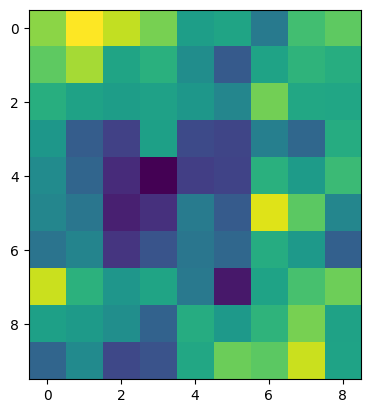

In [45]:
plt.imshow(output[0,0,:,:])